# 1. Import & config $ data loader

In [ ]:
import sys
from pathlib import Path
import itertools 
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from tqdm import tqdm
from natsort import natsorted
import matplotlib.pyplot as plt
from itertools import islice
import csv
from Condition_model.cond_sampler import CondSampler

from diffusion_networks import SongUNet
from dataset import SQGLeadTimeDataset, DATA_100, DATA_500


# ── data ──────────────────────────────────────────────────────────────────
DATA_DIR = DATA_100  # change to DATA_3H for 3-hour data
DATA_STD = 2660.0    # normalisation std (mean assumed 0)

# ── model ─────────────────────────────────────────────────────────────────
IMG_CHANNELS   = 2    # SQG has 2 vertical levels
IMG_RESOLUTION = 64
FILTERS        = 32
LABEL_DROPOUT  = 0.1

# ── training ──────────────────────────────────────────────────────────────
BATCH_SIZE   = 16
NUM_EPOCHS   = 300
LR           = 1e-3
WEIGHT_DECAY = 1e-4

# ── evaluation ────────────────────────────────────────────────────────────
N_ENSEMBLE    = 10   # ensemble members per rollout
ODE_STEPS     = 100  # Euler steps per ODE solve
N_INIT        = 20   # number of starting points to average metrics over
TRAIN_FRAC    = 0.8  # must match dataset split
MAX_HORIZON    = 100  # must match dataset normalisation constant

# ── misc ──────────────────────────────────────────────────────────────────
SAVE_PATH = Path('../models/best_model_conditional.pth')
LOG_PATH  = Path('../models/training_log.csv')
SAVE_PATH.parent.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')
print(f'Data:   {DATA_DIR}')

Device: cuda
Data:   /home/trace/Documents/Projects/Thesis/data


In [3]:
train_dataset = SQGLeadTimeDataset(DATA_DIR, std=DATA_STD, split='train')
val_dataset   = SQGLeadTimeDataset(DATA_DIR, std=DATA_STD, split='val')

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

print(f'Pairs — train: {len(train_dataset)}, val: {len(val_dataset)}')



Pairs — train: 7920, val: 1980


# 2. Check dataset

We expect the dimension of the dataset should be (500, 100, 2, 64, 64), for each trajectory it should be (100, 2, 64, 64), for each batch the first dimension should be 16.

We expect dataset should sample lead time uniformly.
Besides the std(lead_time) abd mean(lead_time) should be stable over time.

In [4]:

prev, curr, tl = train_dataset[0]
print("Single train sample:")
print(f"  initial   : {tuple(prev.shape)}   (expect (C, H, W))")
print(f"  current    : {tuple(curr.shape)}   (expect (C, H, W))")
print(f"  time_label : {'scalar' if tl.ndim == 0 else tuple(tl.shape)}"
f"  value={tl.item():.4f}  (normalised, expect in (0, 1])")

Single train sample:
  initial   : (2, 64, 64)   (expect (C, H, W))
  current    : (2, 64, 64)   (expect (C, H, W))
  time_label : scalar  value=0.0101  (normalised, expect in (0, 1])


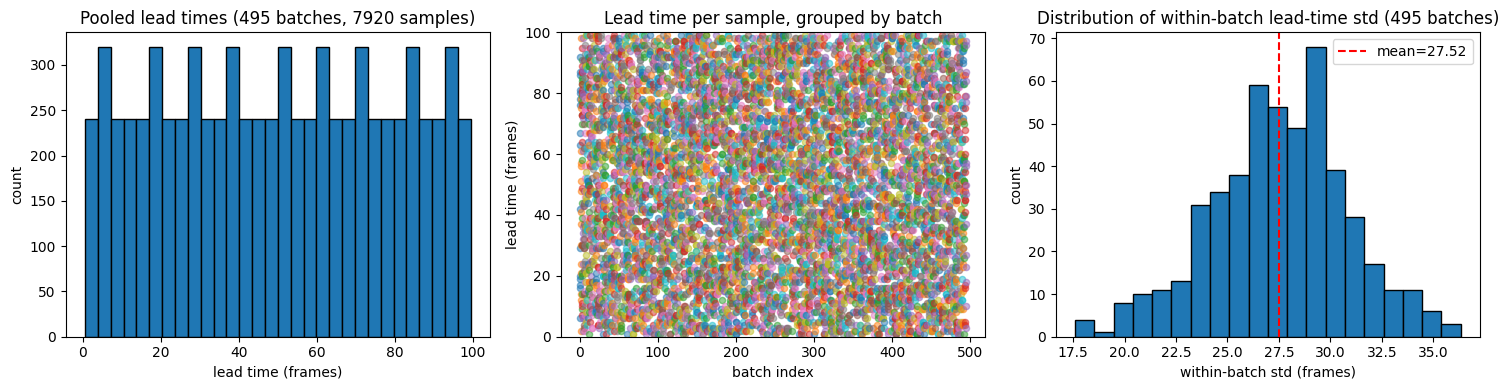

In [8]:
# --- Part 2: Lead-time distribution within / across batches -----------------
# CEWF's DynamicKBatchSampler draws ONE lead time per batch, then varies it
# across batches  ->  within-batch leads CONSTANT, pooled leads ~uniform.
# SQGLeadTimeDataset draws an INDEPENDENT lead in every __getitem__
#                    ->  within-batch leads VARY.
# This cell measures which behaviour we actually have.
hpf     = train_dataset.hours_per_frame   # hours per frame
mh      = train_dataset.max_horizon       # normalisation constant (hours)
n_leads = int(round(mh / hpf))            # number of discrete lead values (frames)
# probe a handful of batches (single-process loader so it spins up fast)
probe_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
batch_leads  = []   # one int-array of lead times (in frames) per batch
for _, _, tl in probe_loader:
    # recover the integer lead in frames from the normalised label
    batch_leads.append((tl.numpy() * mh / hpf).round().astype(int))
    n_collected = len(batch_leads)
    within_batch_std = np.array([lb.std() for lb in batch_leads])

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) pooled lead times -> should be ~uniform over [1, n_leads] frames
all_leads = np.concatenate(batch_leads)
axes[0].hist(all_leads, bins=min(n_leads, 30), range=(0.5, n_leads + 0.5),
             edgecolor='black')
axes[0].set_xlabel('lead time (frames)')
axes[0].set_ylabel('count')
axes[0].set_title(f'Pooled lead times ({n_collected} batches, {all_leads.size} samples)')

# (b) per-sample lead time grouped by batch -> reveals within-batch structure
for bi, lb in enumerate(batch_leads):
    axes[1].scatter(np.full_like(lb, bi), lb, alpha=0.5, s=20)
axes[1].set_xlabel('batch index')
axes[1].set_ylabel('lead time (frames)')
axes[1].set_title('Lead time per sample, grouped by batch')
axes[1].set_ylim(0, n_leads + 1)
if n_leads <= 20:
    axes[1].set_yticks(range(1, n_leads + 1))

# (c) histogram of within-batch standard deviation
axes[2].hist(within_batch_std, bins=20, edgecolor='black')
axes[2].set_xlabel('within-batch std (frames)')
axes[2].set_ylabel('count')
axes[2].set_title(f'Distribution of within-batch lead-time std ({n_collected} batches)')
axes[2].axvline(within_batch_std.mean(), color='red', linestyle='--', 
                label=f'mean={within_batch_std.mean():.2f}')
axes[2].legend()

plt.tight_layout()
plt.show()

# 3. Sampler check

Would this sampler can perform deterministic projection between noise and ($x_{t+\tau}$, lead_time) | $x_0$

In [ ]:
# initialize the dataset but eval mode

check_dataset = SQGLeadTimeDataset(DATA_DIR, std=DATA_STD, split='train', eval_mode=True)
check_loader = DataLoader(check_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)
sampler = CondSampler(model_path="models/best_model_conditional.pth", device=device, steps=100, eps=None)

# loop
for initial, target, tl in itertools.islice(check_loader, 10):
    predict = sampler.sample(initial.to(device), tl.to(device))
    # visualize it, compare to the truth and compute the rmse, should be zero? idk
